# Product demand classification with ADI and CV^2

This notebook classifies demand series into **smooth**, **erratic**, **intermittent**, and **lumpy** demand using the common ADI/CV^2 thresholds.

The default grain is one demand series per `ARTIKEL_ID` and `MARKT_ID`, because the source rows are daily product-store observations. For product-level demand aggregated across all stores instead, set `GROUP_COLS = ["ARTIKEL_ID"]`.

In [55]:
from pathlib import Path
import os

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)

import duckdb
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 80)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (9, 5)

GROUP_COLS = ["ARTIKEL_ID", "MARKT_ID"]
DEMAND_COL = "ABVERKAUFTE_MENGE"
ADI_CUTOFF = 1.32
CV2_CUTOFF = 0.49

candidate_dirs = [
    Path("../data/processed/transactions_dst_over_years"),
    Path("data/processed/transactions_dst_over_years"),
    Path("../../data/processed/transactions_dst_over_days"),
    Path("data/processed/transactions_dst_over_days"),
]
DATA_DIR = next((path for path in candidate_dirs if path.exists()), None)
if DATA_DIR is None:
    raise FileNotFoundError("Could not find the processed transactions directory.")

parquet_files = sorted(DATA_DIR.glob("*.parquet"))
if not parquet_files:
    raise FileNotFoundError(f"No parquet files found in {DATA_DIR}")

print(f"Using {len(parquet_files)} parquet files from {DATA_DIR}")
print(f"Classifying demand series at grain: {', '.join(GROUP_COLS)}")

Using 6 parquet files from ../data/processed/transactions_dst_over_days
Classifying demand series at grain: ARTIKEL_ID, MARKT_ID


## Method

For each demand series:

- **ADI** is `active_days / demand_days`, where demand days have sold quantity above zero.
- **CV^2** is `variance(non-zero demand) / mean(non-zero demand)^2`.
- **Smooth**: `ADI < 1.32` and `CV^2 < 0.49`.
- **Erratic**: `ADI < 1.32` and `CV^2 >= 0.49`.
- **Intermittent**: `ADI >= 1.32` and `CV^2 < 0.49`.
- **Lumpy**: `ADI >= 1.32` and `CV^2 >= 0.49`.

Rows with zero sold amount are retained as active no-sale days, as intended by the prepared data.

Class summaries intentionally avoid total sold quantity because products use different sales units. Quantity totals are only kept at product or product-store level, where units are not mixed within the row.

In [56]:
group_cols_sql = ", ".join(GROUP_COLS)
daily_group_cols_sql = ", ".join([*GROUP_COLS, "sale_date"])
parquet_glob = str(DATA_DIR / "*.parquet")

query = f"""
WITH raw AS (
    SELECT
        {group_cols_sql},
        CAST(DATE AS DATE) AS sale_date,
        CAST(COALESCE({DEMAND_COL}, 0) AS DOUBLE) AS demand
    FROM read_parquet(?)
), daily AS (
    SELECT
        {daily_group_cols_sql},
        SUM(demand) AS demand
    FROM raw
    GROUP BY {daily_group_cols_sql}
), series AS (
    SELECT
        {group_cols_sql},
        COUNT(*) AS active_days,
        SUM(CASE WHEN demand > 0 THEN 1 ELSE 0 END) AS demand_days,
        SUM(demand) AS series_total_demand,
        AVG(CASE WHEN demand > 0 THEN demand END) AS mean_nonzero_demand,
        VAR_SAMP(CASE WHEN demand > 0 THEN demand END) AS var_nonzero_demand,
        MIN(sale_date) AS first_active_day,
        MAX(sale_date) AS last_active_day
    FROM daily
    GROUP BY {group_cols_sql}
)
SELECT
    *,
    active_days / NULLIF(demand_days, 0) AS ADI,
    CASE
        WHEN demand_days > 1 AND mean_nonzero_demand > 0
            THEN var_nonzero_demand / (mean_nonzero_demand * mean_nonzero_demand)
        WHEN demand_days = 1 THEN 0.0
        ELSE NULL
    END AS CV2
FROM series
WHERE demand_days > 0
"""

con = duckdb.connect()
series_metrics = con.execute(query, [parquet_glob]).fetchdf()
series_metrics.head()

,ARTIKEL_ID,MARKT_ID,active_days,demand_days,series_total_demand,mean_nonzero_demand,var_nonzero_demand,first_active_day,last_active_day,ADI,CV2
0,790348,1250038,1009,621.0,145.250,0.233897,0.019347,2021-07-02,2024-10-19,1.624799,0.353645
1,797004,1100026,1520,1294.0,3675.257,2.840230,6.008135,2021-06-28,2026-06-25,1.174652,0.744788
2,797004,1200027,1520,968.0,1236.836,1.277723,0.814738,2021-06-28,2026-06-25,1.570248,0.499050
3,797004,1250052,1518,989.0,949.442,0.960002,0.409931,2021-06-29,2026-06-24,1.534884,0.444802
4,818969,1100025,1519,576.0,592.486,1.028622,1.370740,2021-06-28,2026-06-24,2.637153,1.295519


In [57]:
conditions = [
    (series_metrics["ADI"] < ADI_CUTOFF) & (series_metrics["CV2"] < CV2_CUTOFF),
    (series_metrics["ADI"] < ADI_CUTOFF) & (series_metrics["CV2"] >= CV2_CUTOFF),
    (series_metrics["ADI"] >= ADI_CUTOFF) & (series_metrics["CV2"] < CV2_CUTOFF),
    (series_metrics["ADI"] >= ADI_CUTOFF) & (series_metrics["CV2"] >= CV2_CUTOFF),
]
choices = ["smooth", "erratic", "intermittent", "lumpy"]

series_classification = series_metrics.assign(
    demand_class=np.select(conditions, choices, default="unclassified")
)

# Only keep products where demand lasted more than 10 days
series_classification = series_classification[
    series_classification["demand_days"] >= 10
]

class_order = ["smooth", "erratic", "intermittent", "lumpy"]
class_palette = {
    "smooth": "#2a9d8f",
    "erratic": "#e9c46a",
    "intermittent": "#457b9d",
    "lumpy": "#d62828",
}

product_agg = ("ARTIKEL_ID", "nunique") if "ARTIKEL_ID" in GROUP_COLS else (GROUP_COLS[0], "nunique")
summary = (
    series_classification
    .groupby("demand_class", observed=True)
    .agg(
        series=(GROUP_COLS[0], "size"),
        products=product_agg,
        active_days=("active_days", "sum"),
        demand_days=("demand_days", "sum"),
        median_ADI=("ADI", "median"),
        median_CV2=("CV2", "median"),
    )
    .reindex(class_order)
)
summary["series_share"] = summary["series"] / summary["series"].sum()
summary["observation_share"] = summary["active_days"] / summary["active_days"].sum()

summary_display = summary.copy()
for col in ["series_share", "observation_share"]:
    summary_display[col] = (summary_display[col] * 100).round(1)
summary_display[["median_ADI", "median_CV2"]] = summary_display[["median_ADI", "median_CV2"]].round(2)
summary_display.rename(
    columns={
        "series_share": "series_share_%",
        "observation_share": "observation_share_%",
    }
)

,series,products,active_days,demand_days,median_ADI,median_CV2,series_share_%,observation_share_%
demand_class,,,,,,,,
smooth,4339,826,3887056,3523956.0,1.10,0.42,2.0,2.0
erratic,8287,991,9204339,8000267.0,1.17,0.71,3.8,4.7
intermittent,93527,4167,72849228,11549263.0,9.36,0.34,43.4,37.5
lumpy,109528,3770,108130007,26163157.0,5.68,0.74,50.8,55.7


In [58]:
smooth_share = summary.loc["smooth", "series_share"]
regular_share = summary.loc[["smooth", "erratic"], "series"].sum() / summary["series"].sum()
sparse_share = summary.loc[["intermittent", "lumpy"], "series"].sum() / summary["series"].sum()

print(f"Total classified series: {len(series_classification):,}")
print(f"Smooth series share: {smooth_share:.1%}")
print(f"Regular-demand share (smooth + erratic): {regular_share:.1%}")
print(f"Sparse-demand share (intermittent + lumpy): {sparse_share:.1%}")

Total classified series: 215,681
Smooth series share: 2.0%
Regular-demand share (smooth + erratic): 5.9%
Sparse-demand share (intermittent + lumpy): 94.1%


## Products with smooth demand

With the current `ARTIKEL_ID` x `MARKT_ID` classification grain, the list below contains every unique `ARTIKEL_ID` that has at least one smooth product-store demand series. The `smooth_product_store_series` variable keeps the matching store-level rows if you need the exact stores behind the product IDs.

In [59]:
smooth_product_store_series = (
    series_classification
    .loc[
        series_classification["demand_class"].eq("smooth"),
        [*GROUP_COLS, "ADI", "CV2", "active_days", "demand_days"],
    ]
    .sort_values(GROUP_COLS)
)

smooth_product_ids = sorted(smooth_product_store_series["ARTIKEL_ID"].unique())
smooth_product_id_list = pd.DataFrame({"ARTIKEL_ID": smooth_product_ids})

print(f"Products with at least one smooth demand series: {len(smooth_product_ids):,}")

print(smooth_product_store_series.head())

Products with at least one smooth demand series: 826
        ARTIKEL_ID  MARKT_ID       ADI       CV2  active_days  demand_days
55772        49738   1600006  1.005549  0.398150          906        901.0
207796       49765   1300019  1.311475  0.470749         1520       1159.0
308083       52165   1300007  1.241206  0.365057          247        199.0
194838       52170   1100005  1.148718  0.329293          448        390.0
12782        52170   1100008  1.163212  0.388397          449        386.0


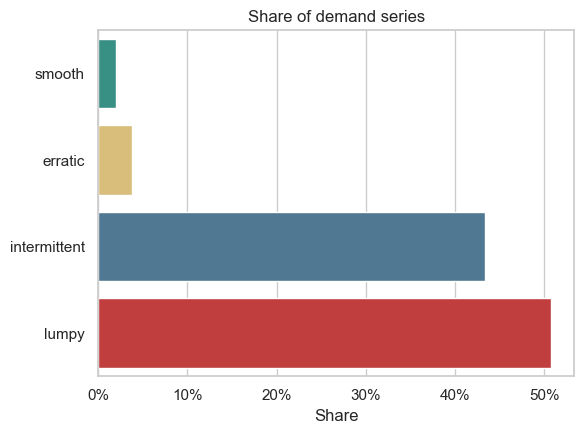

In [60]:
plot_summary = summary.reset_index()

fig, ax = plt.subplots(figsize=(6, 4.5))

sns.barplot(
    data=plot_summary,
    y="demand_class",
    x="series_share",
    order=class_order,
    palette=class_palette,
    hue="demand_class",
    hue_order=class_order,
    legend=False,
    ax=ax,
)

ax.set_title("Share of demand series")
ax.set_xlabel("Share")
ax.set_ylabel("")
ax.xaxis.set_major_formatter(lambda x, _: f"{x:.0%}")

plt.tight_layout()

In [61]:
quantiles = (
    series_classification
    .groupby("demand_class", observed=True)[["ADI", "CV2", "active_days", "demand_days"]]
    .quantile([0.25, 0.50, 0.75])
    .round(2)
)
quantiles

ADI   CV2  active_days  demand_days
demand_class                                            
erratic      0.25   1.08  0.57        662.0        550.5
             0.50   1.17  0.71       1515.0       1181.0
             0.75   1.24  1.19       1520.0       1334.0
intermittent 0.25   4.04  0.26        282.0         18.0
             0.50   9.36  0.34        748.0         40.0
             0.75  23.67  0.42       1279.0        130.0
lumpy        0.25   2.66  0.59        549.0         36.0
             0.50   5.68  0.74       1141.0        116.0
             0.75  14.65  1.04       1483.0        350.0
smooth       0.25   1.03  0.36        317.5        275.0
             0.50   1.10  0.42        975.0        861.0
             0.75   1.20  0.45       1520.0       1328.0